In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import required libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                                     GlobalAveragePooling2D, RandomFlip, RandomRotation,
                                     RandomContrast, RandomZoom, RandomTranslation)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import VGG16, ResNet50
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
# Define data directories
base_dir = '/content/drive/MyDrive/tumor dataset'
train_dir = os.path.join(base_dir, 'Training')
test_dir = os.path.join(base_dir, 'Testing')

In [4]:
# Function to load data
def load_image_data(directory):
    counts = {}
    paths, labels = [], []
    for category in os.listdir(directory):
        category_path = os.path.join(directory, category)
        if os.path.isdir(category_path):
            img_files = os.listdir(category_path)
            counts[category] = len(img_files)
            for img in img_files:
                paths.append(os.path.join(category_path, img))
                labels.append(category)
    return counts, paths, labels

In [5]:
# Load training and testing data
train_counts, train_paths, train_labels = load_image_data(train_dir)
test_counts, test_paths, test_labels = load_image_data(test_dir)

In [6]:
# Create DataFrame to visualize class distributions
df_train = pd.DataFrame(train_counts.items(), columns=['Tumor Type', 'Training Count'])
df_test = pd.DataFrame(test_counts.items(), columns=['Tumor Type', 'Testing Count'])
data_summary = pd.merge(df_train, df_test, on='Tumor Type').set_index('Tumor Type')

In [7]:
# Map classes to numeric labels
classes = sorted(list(set(train_labels)))
class_to_idx = {label: idx for idx, label in enumerate(classes)}

In [8]:
train_label_idx = [class_to_idx[label] for label in train_labels]
test_label_idx = [class_to_idx[label] for label in test_labels]

In [9]:
def visualize_samples(paths, labels, mapping, indices=range(10), size=250, grid=(3, 4)):
    idx_to_label = {v: k for k, v in mapping.items()}
    plt.figure(figsize=(12, 8))
    for i, idx in enumerate(indices):
        if idx >= len(paths):
            continue
        img = load_img(paths[idx], target_size=(size, size))
        plt.subplot(grid[0], grid[1], i + 1)
        plt.imshow(img)
        plt.title(f'{idx_to_label[labels[idx]]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

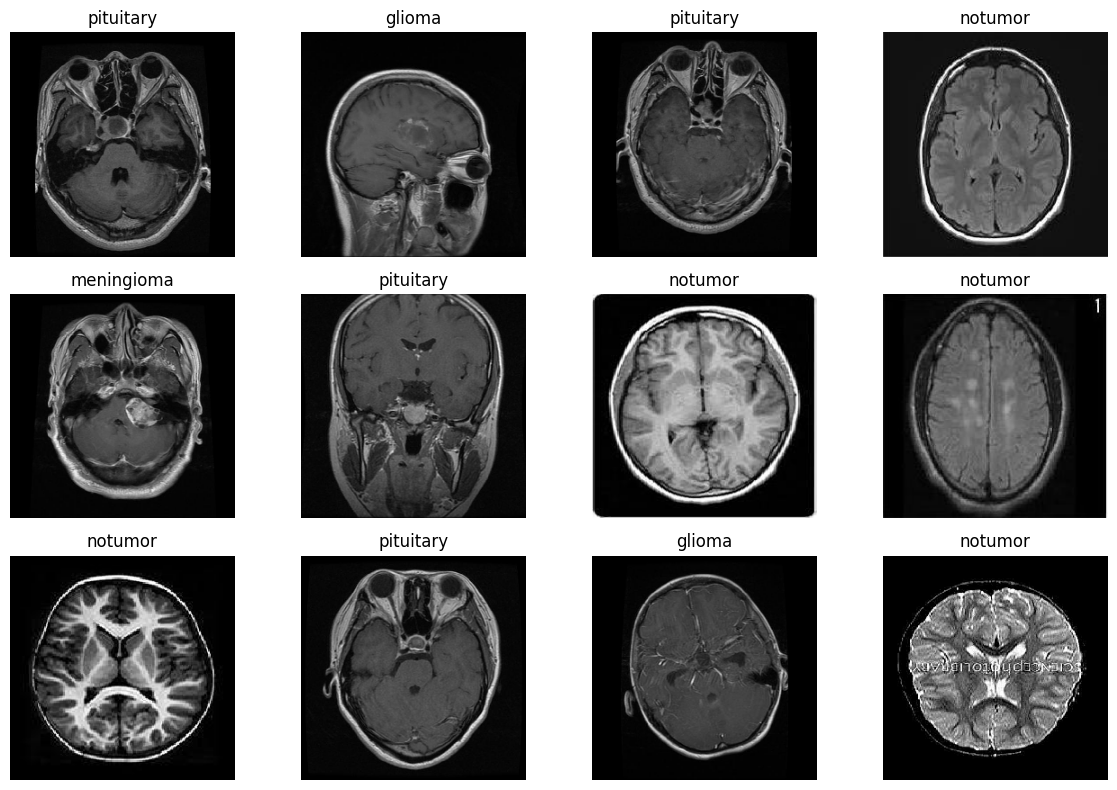

In [10]:
# Shuffle and visualize samples
combined = list(zip(train_paths, train_label_idx))
random.shuffle(combined)
train_paths, train_label_idx = zip(*combined)
visualize_samples(train_paths, train_label_idx, class_to_idx, indices=range(12))

In [11]:
# Data augmentation pipeline
augment_pipeline = Sequential([
    RandomFlip('horizontal'),
    RandomRotation(0.02, fill_mode='constant'),
    RandomContrast(0.1),
    RandomZoom(height_factor=0.01, width_factor=0.05),
    RandomTranslation(height_factor=0.0015, width_factor=0.0015, fill_mode='constant')
])


In [12]:
img_size = (250, 250)
batch = 32

In [13]:
# Functions for reading and preprocessing data
def load_and_preprocess_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    return img, label

In [14]:
def training_preprocessing(img, label):
    img = augment_pipeline(img) / 255.0
    return img, label

def testing_preprocessing(img, label):
    return img / 255.0, label

# Create TensorFlow datasets
train_ds = tf.data.Dataset.from_tensor_slices((list(train_paths), list(train_label_idx)))
train_ds = train_ds.map(load_and_preprocess_image).map(training_preprocessing)
test_ds = tf.data.Dataset.from_tensor_slices((list(test_paths), list(test_label_idx)))
test_ds = test_ds.map(load_and_preprocess_image).map(testing_preprocessing)

# Prepare batches
dataset_train = train_ds.batch(batch).prefetch(buffer_size=tf.data.AUTOTUNE)
dataset_test = test_ds.batch(batch).prefetch(buffer_size=tf.data.AUTOTUNE)

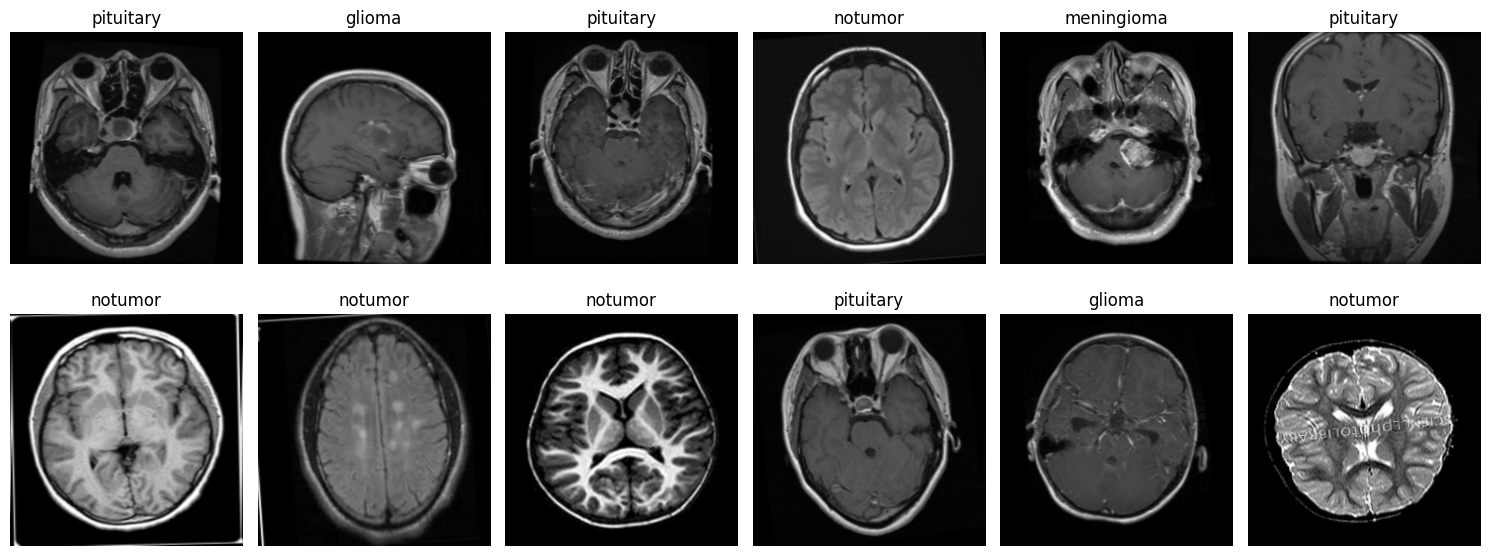

In [15]:
# Display augmented images
def show_augmented_images(ds, mapping, grid_shape=(2, 6)):
    idx_to_label = {v: k for k, v in mapping.items()}
    plt.figure(figsize=(15, 6))
    for img, label in ds.take(1):
        for i in range(grid_shape[0] * grid_shape[1]):
            plt.subplot(grid_shape[0], grid_shape[1], i+1)
            plt.imshow(img[i].numpy())
            plt.title(idx_to_label[label.numpy()[i]])
            plt.axis('off')
    plt.tight_layout()
    plt.show()

show_augmented_images(dataset_train, class_to_idx)

In [16]:
# Setup model parameters
num_classes = len(classes)
input_shape = (img_size[0], img_size[1], 3)

# Encode labels to one-hot
one_hot = lambda img, lbl: (img, tf.one_hot(lbl, depth=num_classes))
dataset_train = dataset_train.map(one_hot)
dataset_test = dataset_test.map(one_hot)

In [17]:
# Build CNN Model
def create_cnn_model(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        Conv2D(64, (5,5), activation='relu'),
        MaxPooling2D(pool_size=(3,3)),
        Conv2D(128, (4,4), activation='relu'),
        MaxPooling2D(pool_size=(2,2)),
        Conv2D(128, (4,4), activation='relu'),
        MaxPooling2D(pool_size=(2,2)),
        Flatten(),
        Dense(512, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    return model

In [18]:
model = create_cnn_model(input_shape, num_classes)
optimizer = Adam(learning_rate=0.001, beta_1=0.85, beta_2=0.9925)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [19]:
class DynamicLearningRate(tf.keras.callbacks.Callback):
    """
    Custom callback to reduce learning rate when accuracy hits specified thresholds.
    """
    def __init__(self, thresholds, factor, monitor='val_accuracy'):
        super().__init__()
        self.thresholds = thresholds
        self.factor = factor
        self.monitor = monitor
        self.hit = [False] * len(thresholds)

    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get(self.monitor)
        if acc is None:
            return

        for i, threshold in enumerate(self.thresholds):
            if acc >= threshold and not self.hit[i]:
                lr = self.model.optimizer.learning_rate

                if not isinstance(lr, tf.Variable):
                    lr = tf.Variable(lr, dtype=tf.float32)
                    self.model.optimizer.learning_rate = lr

                old_lr = float(tf.keras.backend.get_value(lr))
                new_lr = old_lr * self.factor
                lr.assign(new_lr)

                self.hit[i] = True
                print(f"\nEpoch {epoch+1}: {self.monitor} ≥ {threshold:.4f} → "
                      f"LR reduced from {old_lr:.6f} → {new_lr:.6f}")

In [20]:
# Callbacks
thresholds = [0.96, 0.99, 0.9935]
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', patience=4, factor=0.8, min_lr=1e-4),
    ModelCheckpoint('cnn_model.keras', monitor='val_accuracy', save_best_only=True, verbose=0),
    DynamicLearningRate(thresholds=thresholds, factor=0.75)
]

In [21]:
# Train model
cnn_hist = model.fit(dataset_train, validation_data=dataset_test, epochs=50, callbacks=callbacks, verbose=True)

Epoch 1/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 562s 3s/step - accuracy: 0.5681 - loss: 1.1818 - val_accuracy: 0.7040 - val_loss: 0.7429 - learning_rate: 0.0010
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 103s 574ms/step - accuracy: 0.8129 - loss: 0.4881 - val_accuracy: 0.7902 - val_loss: 0.5064 - learning_rate: 0.0010
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 103s 573ms/step - accuracy: 0.8719 - loss: 0.3422 - val_accuracy: 0.8322 - val_loss: 0.4727 - learning_rate: 0.0010
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 102s 572ms/step - accuracy: 0.9075 - loss: 0.2547 - val_accuracy: 0.9024 - val_loss: 0.2673 - learning_rate: 0.0010
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 103s 570ms/step - accuracy: 0.9225 - loss: 0.2007 - val_accuracy: 0.9115 - val_loss: 0.2584 - learning_rate: 0.0010
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 103s 572ms/step - accuracy: 0.9486 - loss: 0.1483 - val_accuracy: 0.9222 - val_loss: 0.2634 - learning_rate: 0.0010
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 103s 574ms/step - accuracy:

In [22]:
# Load best model
cnn_model = load_model('cnn_model.keras')

# Evaluate
train_loss, train_acc = model.evaluate(dataset_train)
print(f'Training Accuracy: {train_acc*100:.2f}%')

val_loss, val_acc = model.evaluate(dataset_test)
print(f'Testing Accuracy: {val_acc*100:.2f}%')

179/179 ━━━━━━━━━━━━━━━━━━━━ 101s 561ms/step - accuracy: 0.9995 - loss: 0.0012
Training Accuracy: 99.95%
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9905 - loss: 0.0797
Testing Accuracy: 98.93%


In [23]:
# Plot Accuracy & Loss
def plot_training_history(history):
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    axs[0].plot(history.history['accuracy'], label='Training Acc')
    axs[0].plot(history.history['val_accuracy'], label='Validation Acc')
    axs[0].set_title('Model Accuracy')
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(history.history['loss'], label='Training Loss')
    axs[1].plot(history.history['val_loss'], label='Validation Loss')
    axs[1].set_title('Model Loss')
    axs[1].legend()
    axs[1].grid(True)
    plt.show()

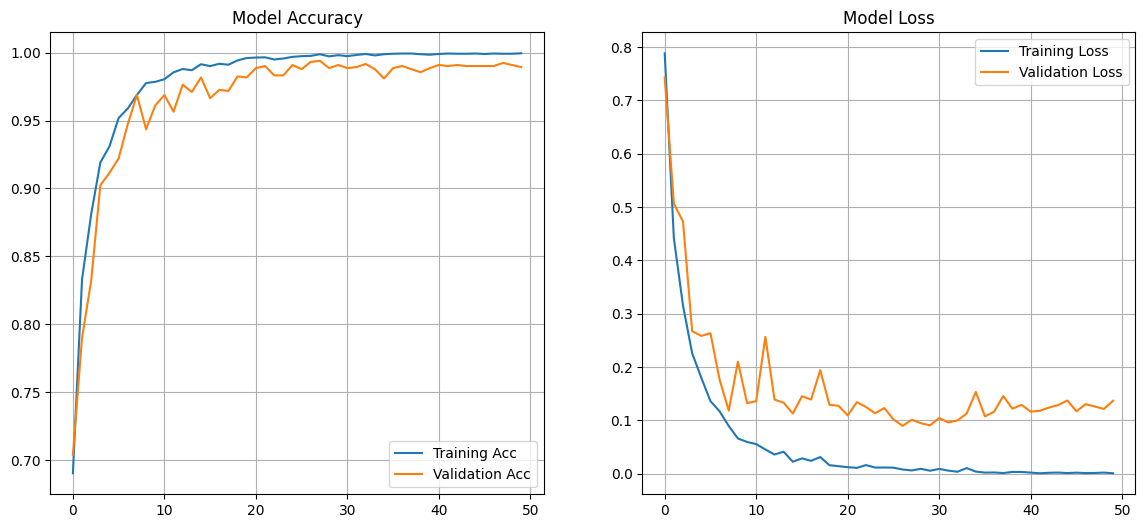

In [24]:
plot_training_history(cnn_hist)

In [25]:
def evaluate_model_performance(model, dataset, mapping):
    """
    Evaluate model performance and display confusion matrix and classification report.
    """

    # Batch prediction
    predictions = model.predict(dataset, verbose=0)

    # True labels
    y_true = []
    for _, labels in dataset:
        y_true.append(labels.numpy())
    y_true = np.concatenate(y_true, axis=0)

    if y_true.ndim > 1:
        y_true = np.argmax(y_true, axis=1)

    y_pred = np.argmax(predictions, axis=1)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=list(mapping.values()),
                yticklabels=list(mapping.values()))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # Classification report
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=list(mapping.values())))

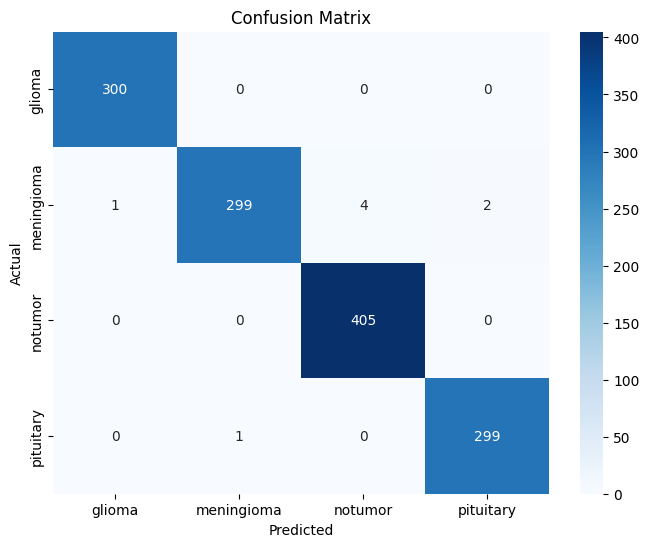


Classification Report:

              precision    recall  f1-score   support

      glioma       1.00      1.00      1.00       300
  meningioma       1.00      0.98      0.99       306
     notumor       0.99      1.00      1.00       405
   pituitary       0.99      1.00      1.00       300

    accuracy                           0.99      1311
   macro avg       0.99      0.99      0.99      1311
weighted avg       0.99      0.99      0.99      1311



In [26]:
# Evaluate Performance
reverse_class_idx = {v: k for k, v in class_to_idx.items()}
evaluate_model_performance(cnn_model, dataset_test, reverse_class_idx)

In [27]:
# Function to visualize sample predictions
def visualize_predictions(model, prediction_folder, class_mapping, figsize=(13, 12)):
    """
    Display images along with their true labels and predicted labels.
    """
    plt.figure(figsize=figsize)
    true_classes, image_paths = [], []

    # Collect all images and true labels
    for class_folder in os.listdir(prediction_folder):
        class_path = os.path.join(prediction_folder, class_folder)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('jpg', 'jpeg', 'png')):
                    image_paths.append(os.path.join(class_path, img_name))
                    true_classes.append(class_folder)

    if not image_paths:
        print("No images found in the specified directory.")
        return

    total_samples = len(image_paths)
    columns = int(np.sqrt(total_samples))
    rows = (total_samples // columns) + (total_samples % columns > 0)

    # Display images with predictions
    for idx, img_path in enumerate(image_paths):
        img = Image.open(img_path).resize((250, 250))
        img_array = np.array(img) / 255.0
        img_batch = np.expand_dims(img_array, axis=0)

        pred = model.predict(img_batch, verbose=False)
        predicted_idx = np.argmax(pred, axis=1)[0]
        predicted_class = class_mapping[predicted_idx]
        true_class = true_classes[idx]

        plt.subplot(rows, columns, idx + 1)
        plt.imshow(img)
        plt.title(f"True: {true_class}\nPred: {predicted_class}", color='green')
        plt.axis('off')

    plt.tight_layout()
    plt.show()


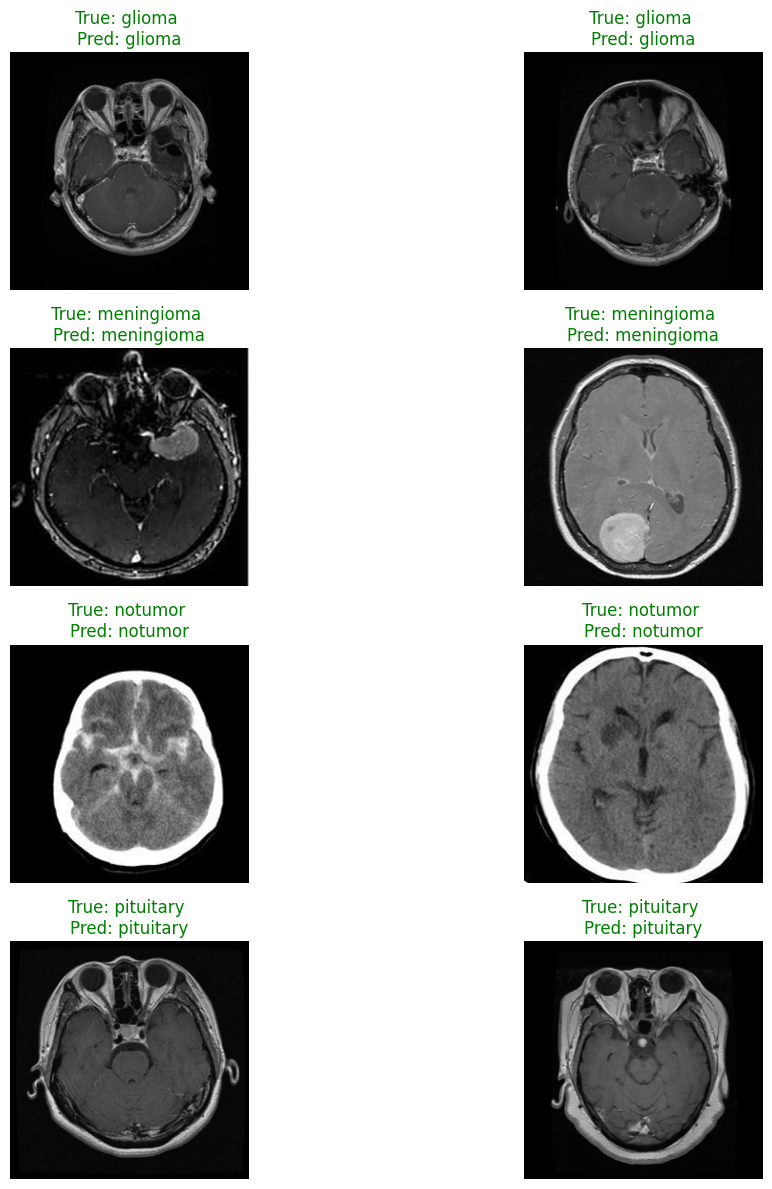

In [28]:
prediction_folder = '/content/drive/MyDrive/tumor dataset/TumorPrediction'
visualize_predictions(model, prediction_folder, reverse_class_idx)

In [29]:
# Function to visualize misclassified images
def display_misclassified_images(model, dataset, class_mapping, max_display=20, figsize=(10, 6)):
    """
    Display incorrectly classified images from the test dataset.
    """
    wrong_images, actual_labels, predicted_labels = [], [], []

    for img, label in dataset.unbatch():
        img_batch = tf.expand_dims(img, 0)
        prediction = model.predict(img_batch, verbose=False)
        pred_label = np.argmax(prediction)
        true_label = np.argmax(label.numpy())

        if pred_label != true_label:
            wrong_images.append(img.numpy())
            actual_labels.append(class_mapping[true_label])
            predicted_labels.append(class_mapping[pred_label])

        if len(wrong_images) >= max_display:
            break

    if not wrong_images:
        print("No misclassified samples found.")
        return

    total_wrong = len(wrong_images)
    cols = int(np.sqrt(total_wrong)) + 1
    rows = (total_wrong // cols) + (total_wrong % cols > 0)

    plt.figure(figsize=figsize)

    for i in range(total_wrong):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(wrong_images[i])
        plt.title(f"True: {actual_labels[i]}\nPred: {predicted_labels[i]}", color='red')
        plt.axis('off')

    plt.tight_layout()
    plt.show()


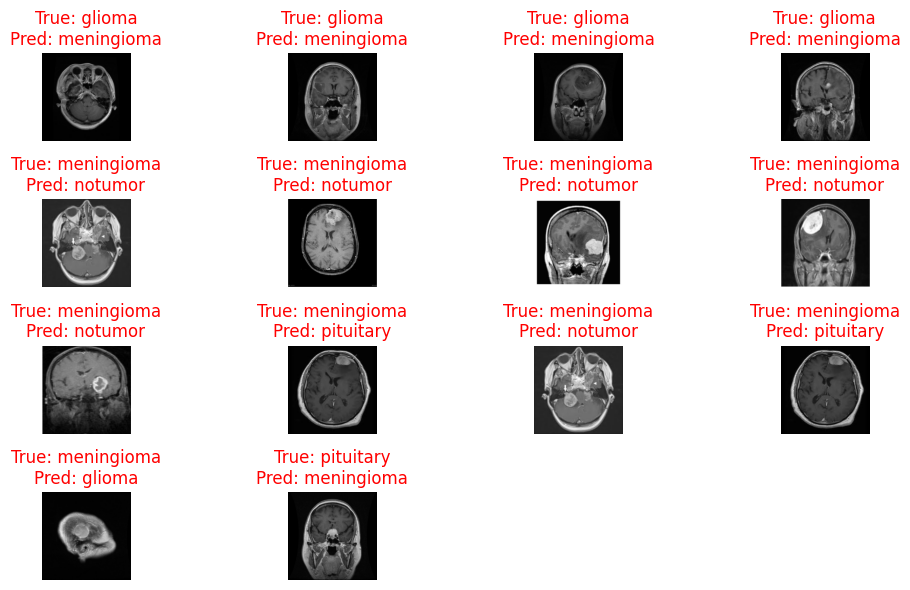

In [30]:
display_misclassified_images(model, dataset_test, reverse_class_idx, figsize=(10, 6))

In [31]:
# Function to create a VGG16-based CNN model
def build_vgg16_cnn_model(input_shape, num_classes):
    """
    Initialize a CNN model using pre-trained VGG16 as the base.
    """
    base_model = VGG16(include_top=False, weights='imagenet', input_shape=input_shape)

    # Freeze early layers, fine-tune a few top layers
    for layer in base_model.layers:
        layer.trainable = False
    for layer in base_model.layers[-4:]:
        layer.trainable = True

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = Flatten()(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

In [32]:
# Build and compile the model
vgg16_model = build_vgg16_cnn_model(input_shape=input_shape, num_classes=num_classes)
vgg16_model.compile(optimizer=Adam(learning_rate=0.0001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# Set up callbacks
vgg16_checkpoint_path = 'vgg16_cnn_model.keras'
vgg16_callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.8, patience=4, min_lr=1e-4, verbose=0),
    ModelCheckpoint(filepath=vgg16_checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=0),
    DynamicLearningRate(thresholds=[0.96, 0.99, 0.9935], factor=0.75)
]

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [33]:
# Train the model
vgg16_history = vgg16_model.fit(
    dataset_train,
    validation_data=dataset_test,
    epochs=10,
    callbacks=vgg16_callbacks,
    verbose=True
)


Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 113s 591ms/step - accuracy: 0.7122 - loss: 0.7159 - val_accuracy: 0.8719 - val_loss: 0.3231 - learning_rate: 1.0000e-04
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 103s 573ms/step - accuracy: 0.9194 - loss: 0.2309 - val_accuracy: 0.9001 - val_loss: 0.2699 - learning_rate: 1.0000e-04
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 103s 574ms/step - accuracy: 0.9387 - loss: 0.1617 - val_accuracy: 0.9108 - val_loss: 0.2198 - learning_rate: 1.0000e-04
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 103s 573ms/step - accuracy: 0.9581 - loss: 0.1131 - val_accuracy: 0.9527 - val_loss: 0.1373 - learning_rate: 1.0000e-04
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.9735 - loss: 0.0760
Epoch 5: val_accuracy ≥ 0.9600 → LR reduced from 0.000100 → 0.000075
179/179 ━━━━━━━━━━━━━━━━━━━━ 103s 573ms/step - accuracy: 0.9735 - loss: 0.0760 - val_accuracy: 0.9710 - val_loss: 0.0744 - learning_rate: 1.0000e-04
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 103s 574ms/ste

In [34]:
# Load the model after training
vgg16_model = load_model(vgg16_checkpoint_path)

# Evaluate on training and testing sets
train_loss, train_acc = vgg16_model.evaluate(dataset_train)
print(f'VGG16 Model - Training Accuracy: {train_acc*100:.2f}%')

test_loss, test_acc = vgg16_model.evaluate(dataset_test)
print(f'VGG16 Model - Testing Accuracy: {test_acc*100:.2f}%')

179/179 ━━━━━━━━━━━━━━━━━━━━ 101s 560ms/step - accuracy: 0.9867 - loss: 0.0408
VGG16 Model - Training Accuracy: 98.84%
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9741 - loss: 0.0948
VGG16 Model - Testing Accuracy: 98.02%


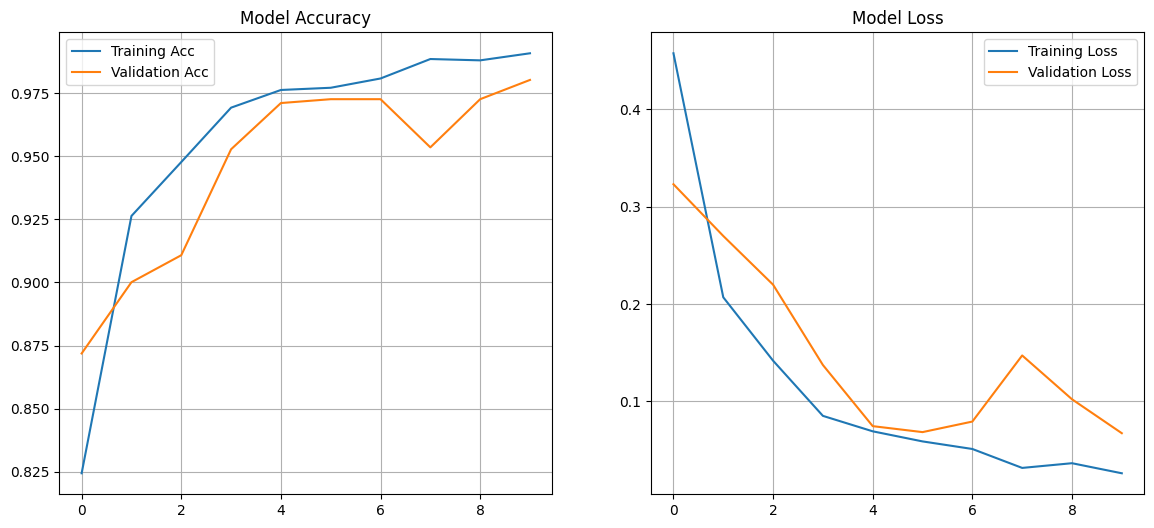

In [35]:
plot_training_history(vgg16_history)

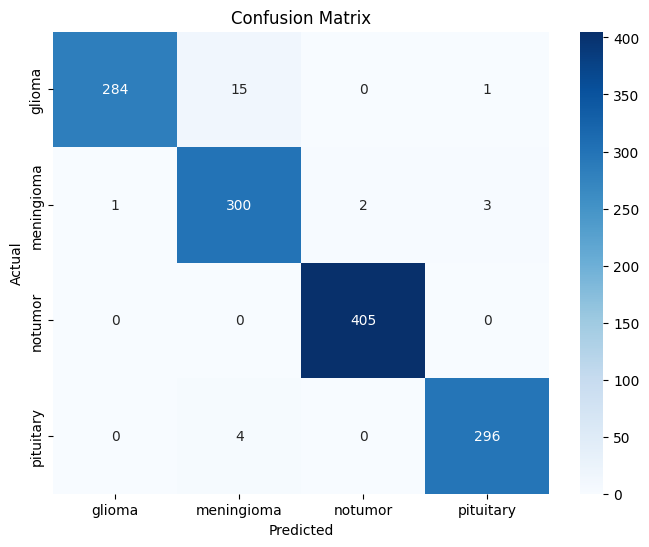


Classification Report:

              precision    recall  f1-score   support

      glioma       1.00      0.95      0.97       300
  meningioma       0.94      0.98      0.96       306
     notumor       1.00      1.00      1.00       405
   pituitary       0.99      0.99      0.99       300

    accuracy                           0.98      1311
   macro avg       0.98      0.98      0.98      1311
weighted avg       0.98      0.98      0.98      1311



In [36]:
evaluate_model_performance(vgg16_model, dataset_test, reverse_class_idx)

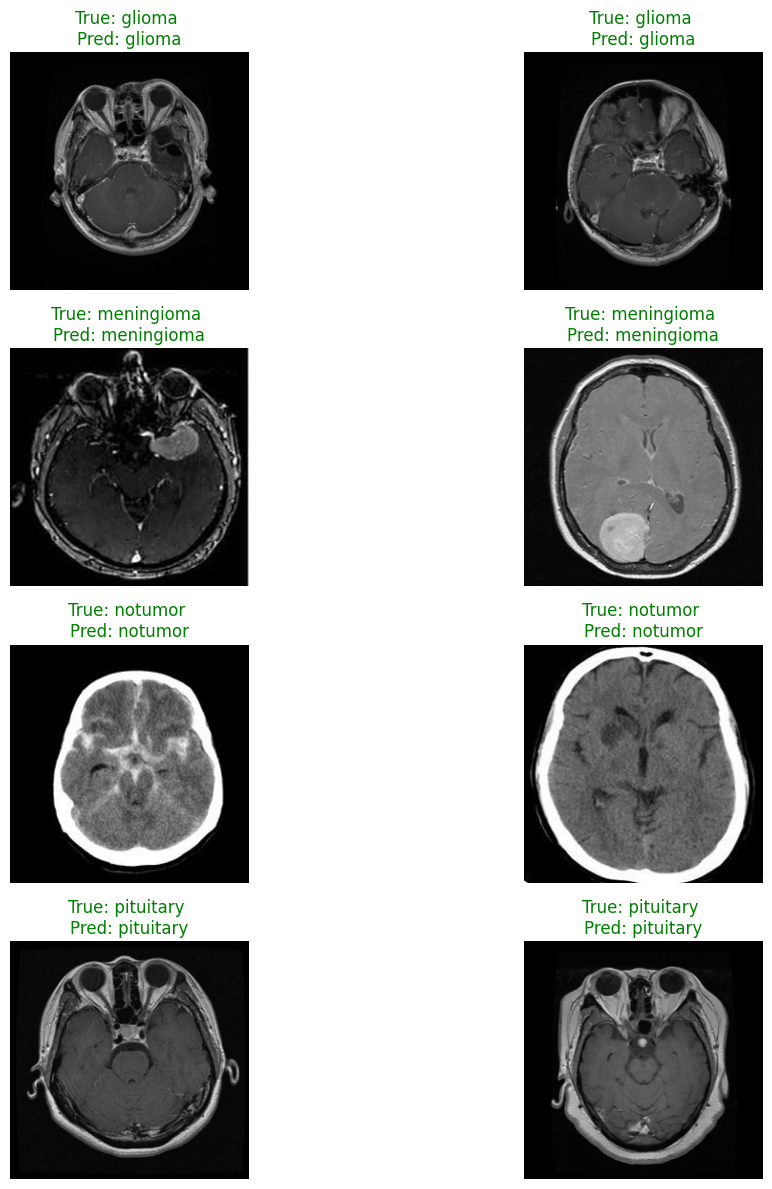

In [37]:
prediction_folder = '/content/drive/MyDrive/tumor dataset/TumorPrediction'
visualize_predictions(model, prediction_folder, reverse_class_idx)

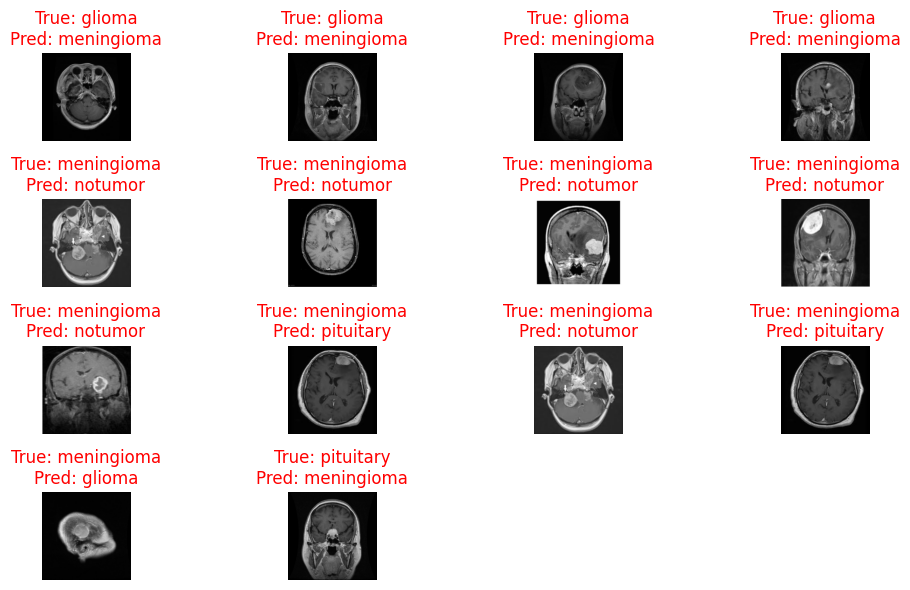

In [38]:
display_misclassified_images(model, dataset_test, reverse_class_idx, figsize=(10, 6))

In [39]:
# Function to build a ResNet50-based transfer learning model
def build_resnet50_model(input_shape, num_classes):
    """
    Initialize a ResNet50 model for transfer learning.
    """
    base_model = ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)

    # Freeze all layers initially
    for layer in base_model.layers:
        layer.trainable = False

    # Add custom head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)
    return model

In [40]:
# Set input shape and epochs
resnet_input_shape = (img_size[0], img_size[1], 3)

# Build and compile ResNet50 model
resnet_model = build_resnet50_model(resnet_input_shape, num_classes)
resnet_model.compile(optimizer=Adam(learning_rate=0.0001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

# Train ResNet50 model
resnet_history = resnet_model.fit(
    dataset_train,
    validation_data=dataset_test,
    epochs=25,
    verbose=True
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 121s 606ms/step - accuracy: 0.3083 - loss: 1.4594 - val_accuracy: 0.4889 - val_loss: 1.2268
Epoch 2/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 101s 565ms/step - accuracy: 0.4570 - loss: 1.2238 - val_accuracy: 0.5133 - val_loss: 1.1778
Epoch 3/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 101s 566ms/step - accuracy: 0.5226 - loss: 1.1537 - val_accuracy: 0.5629 - val_loss: 1.1504
Epoch 4/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 102s 566ms/step - accuracy: 0.5574 - loss: 1.1077 - val_accuracy: 0.5774 - val_loss: 1.1246
Epoch 5/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 101s 566ms/step - accuracy: 0.5900 - loss: 1.0709 - val_accuracy: 0.5881 - val_loss: 1.1072
Epoch 6/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 101s 566ms/step - accuracy: 0.6021 - loss: 1.0452 - val_accuracy: 0.5995 - val_loss: 1.0822
Epoch 7/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 101s 565ms/step - accuracy: 0.6313 - loss: 1.0140 - val_accuracy: 0.6018 - val_loss: 1.0727
Epoch 8/25
179/179 ━━━━━━

In [41]:
# Save and reload the model
resnet_model.save('resnet50_transfer_model.keras')
loaded_resnet_model = load_model('resnet50_transfer_model.keras')

# Evaluate performance
train_loss, train_acc = loaded_resnet_model.evaluate(dataset_train)
test_loss, test_acc = loaded_resnet_model.evaluate(dataset_test)

print(f'ResNet50 Training Accuracy: {train_acc*100:.2f}%')
print(f'ResNet50 Testing Accuracy: {test_acc*100:.2f}%')

179/179 ━━━━━━━━━━━━━━━━━━━━ 105s 556ms/step - accuracy: 0.7124 - loss: 0.7333
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.6766 - loss: 0.7970
ResNet50 Training Accuracy: 70.89%
ResNet50 Testing Accuracy: 65.60%


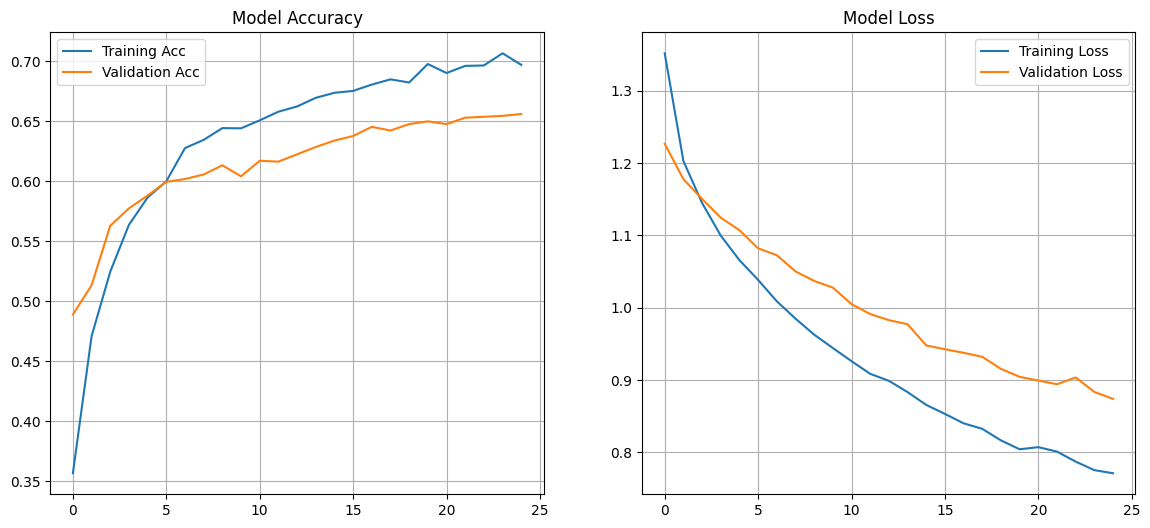

In [42]:
plot_training_history(resnet_history)

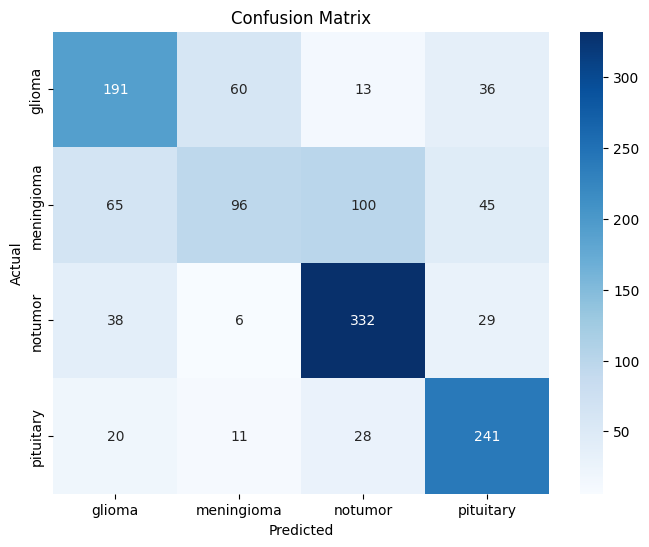


Classification Report:

              precision    recall  f1-score   support

      glioma       0.61      0.64      0.62       300
  meningioma       0.55      0.31      0.40       306
     notumor       0.70      0.82      0.76       405
   pituitary       0.69      0.80      0.74       300

    accuracy                           0.66      1311
   macro avg       0.64      0.64      0.63      1311
weighted avg       0.64      0.66      0.64      1311



In [43]:
evaluate_model_performance(loaded_resnet_model, dataset_test, reverse_class_idx)

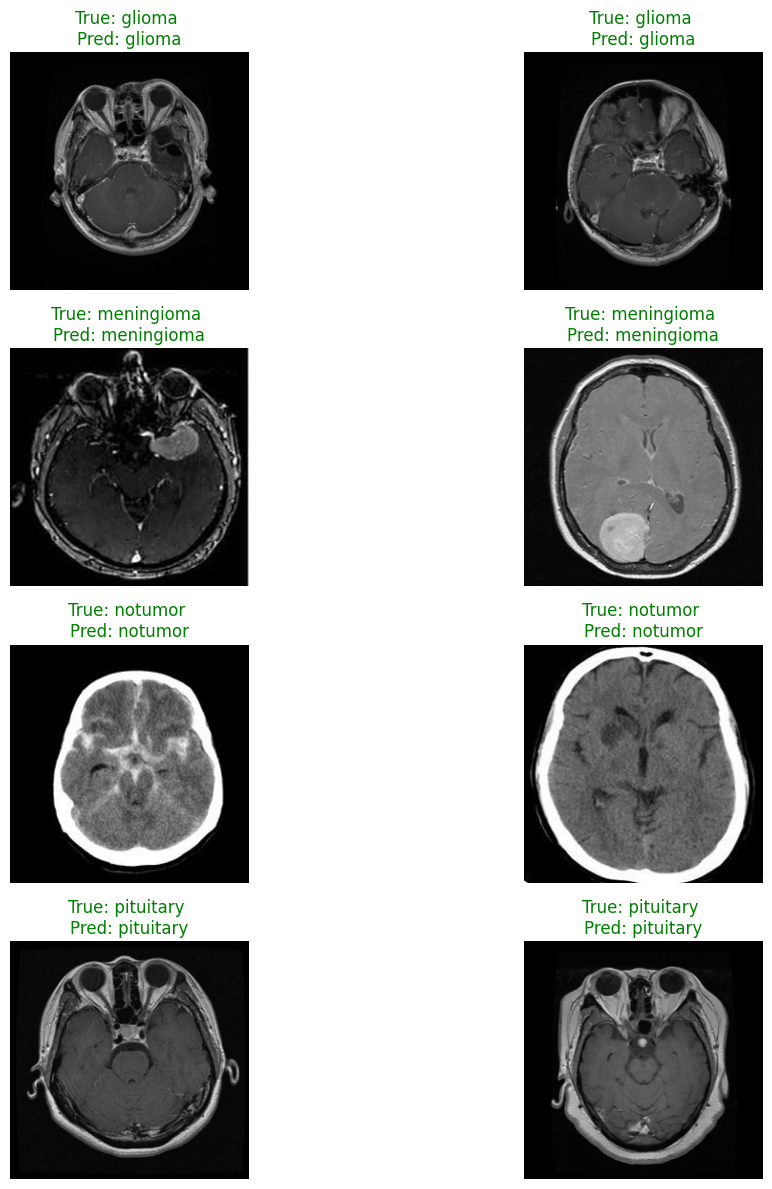

In [44]:
prediction_folder = '/content/drive/MyDrive/tumor dataset/TumorPrediction'
visualize_predictions(model, prediction_folder, reverse_class_idx)

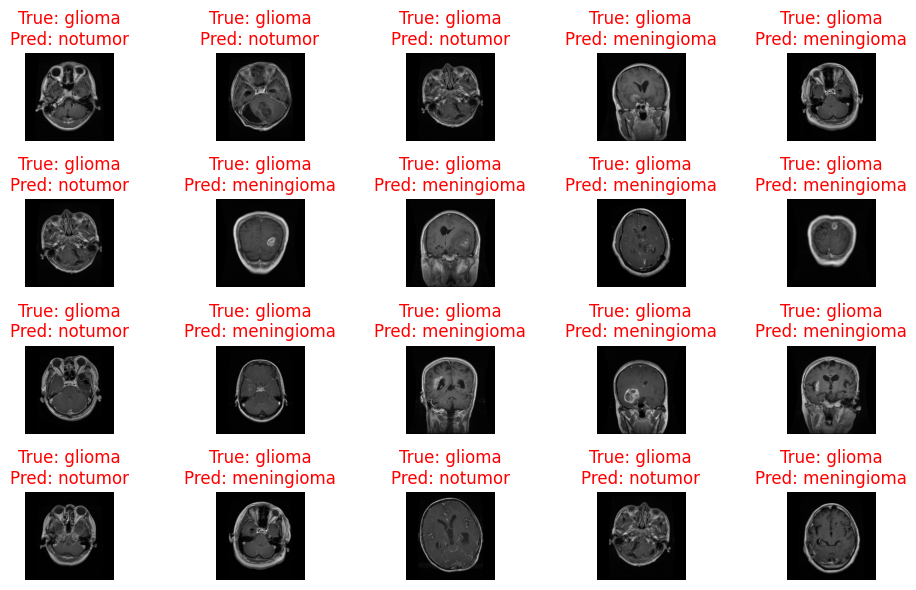

In [45]:
display_misclassified_images(loaded_resnet_model, dataset_test, reverse_class_idx, figsize=(10, 6))

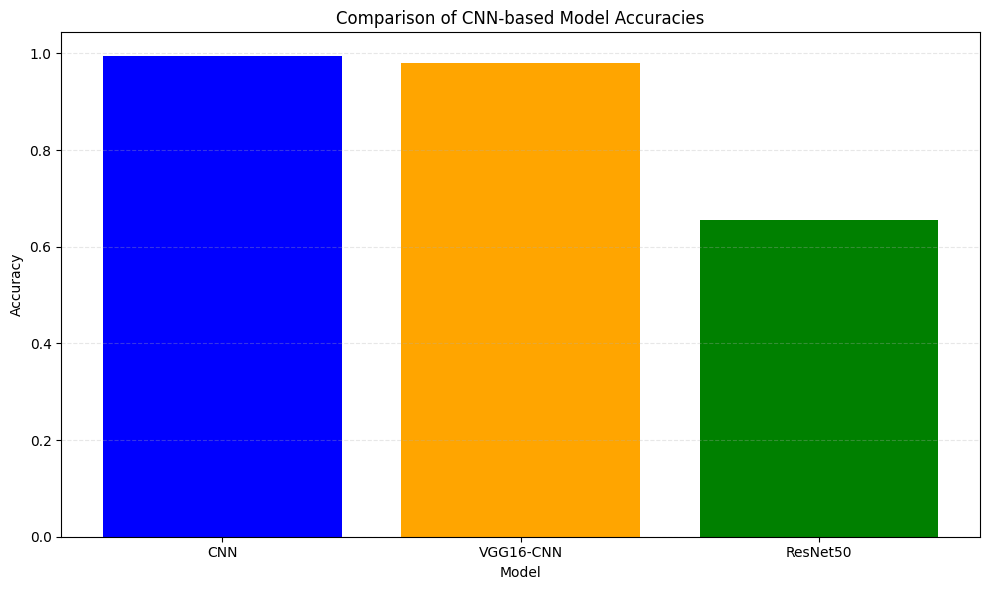

In [53]:
# Evaluate models
_, cnn_acc = cnn_model.evaluate(dataset_test, verbose=0)
_, vgg16_acc = vgg16_model.evaluate(dataset_test, verbose=0)
_, resnet_acc = resnet_model.evaluate(dataset_test, verbose=0)

# Accuracy dictionary for plotting
model_accuracy = {
    'CNN': cnn_acc,
    'VGG16-CNN': vgg16_acc,
    'ResNet50': resnet_acc
}

# Plotting
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bar_colors = ['blue', 'orange', 'green']
plt.bar(model_accuracy.keys(), model_accuracy.values(), color=bar_colors)

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Comparison of CNN-based Model Accuracies')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()




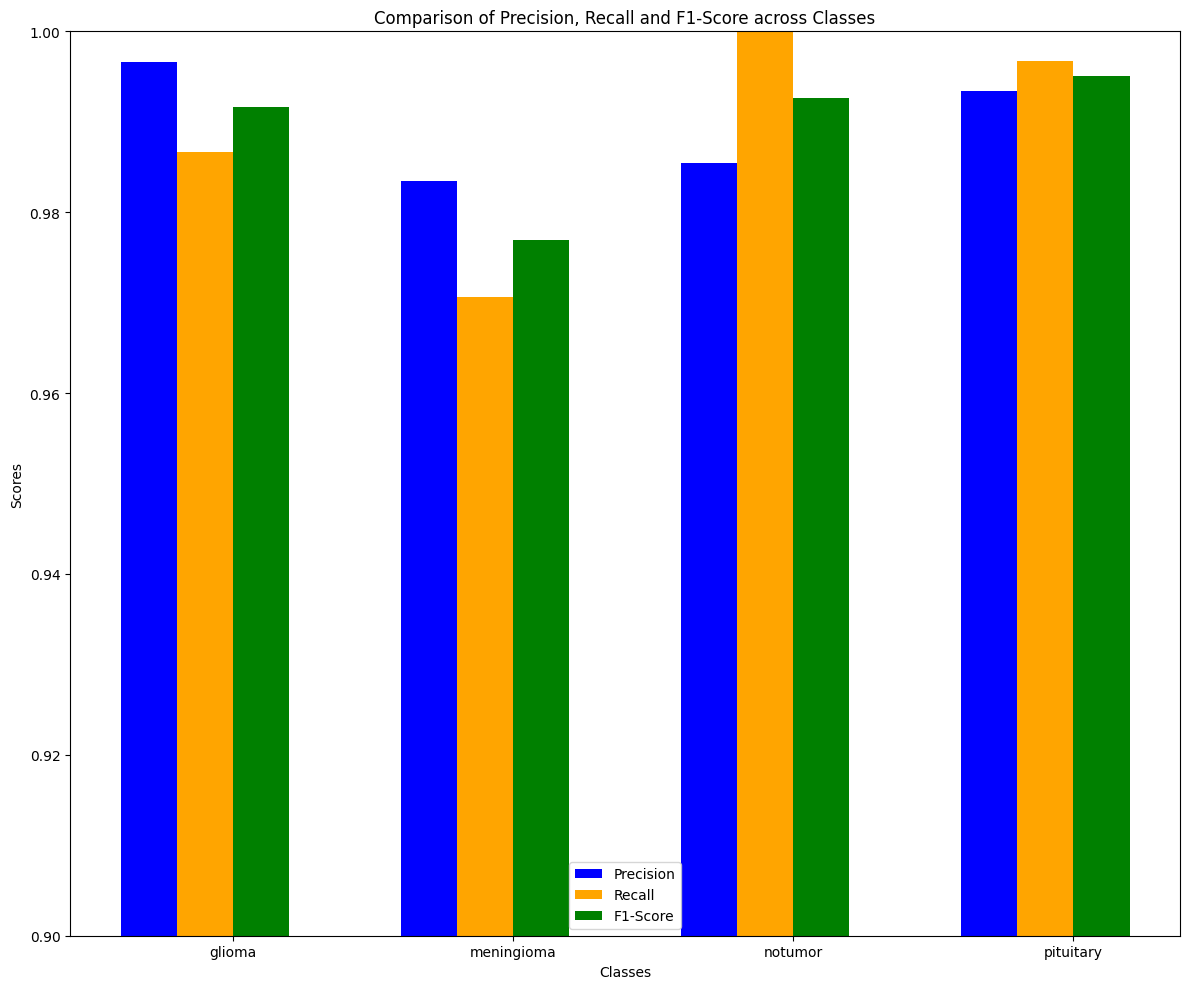

In [62]:
# Step 1: Predict and collect labels
y_true = []
y_pred = []

for images, labels in dataset_test:
    true_classes = np.argmax(labels.numpy(), axis=1)
    y_true.extend(true_classes)

    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    y_pred.extend(predicted_classes)

# Step 2: Classification report as dictionary
class_names = list(reverse_class_idx.values())
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

# Step 3: Extract metrics
precision = [report[class_name]['precision'] for class_name in class_names]
recall = [report[class_name]['recall'] for class_name in class_names]
f1_score = [report[class_name]['f1-score'] for class_name in class_names]

x = np.arange(len(class_names))
bar_width = 0.2

# Step 4: Plotting
plt.figure(figsize=(12, 10))

plt.bar(x, precision, width=bar_width, label='Precision', color='Blue')
plt.bar(x + bar_width, recall, width=bar_width, label='Recall', color='Orange')
plt.bar(x + 2 * bar_width, f1_score, width=bar_width, label='F1-Score', color='Green')

plt.xlabel('Classes')
plt.ylabel('Scores')
plt.title('Comparison of Precision, Recall and F1-Score across Classes')
plt.xticks(x + 1.5*bar_width, class_names)
plt.ylim(0.9,1)
plt.legend()
plt.tight_layout()
plt.show()
